# Visualization of a classification tree partitioning

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Data
np.random.seed(0)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Parameters
n_clusters = 10   # total clusters
n_classes = 2    # final classes
n_samples = 600

# Generate clusters
X, cluster_ids = make_blobs(
    n_samples=n_samples,
    centers=n_clusters,
    cluster_std=0.8,
    random_state=42
)

# Map clusters -> classes (many clusters per class)
y = cluster_ids % n_classes










# Model fitting

In [34]:
max_depth = 20
models = []
for d in range(1, max_depth + 1):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X, y)
    models.append(clf)

# Grid for decision regions
h = 0.1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Visualization

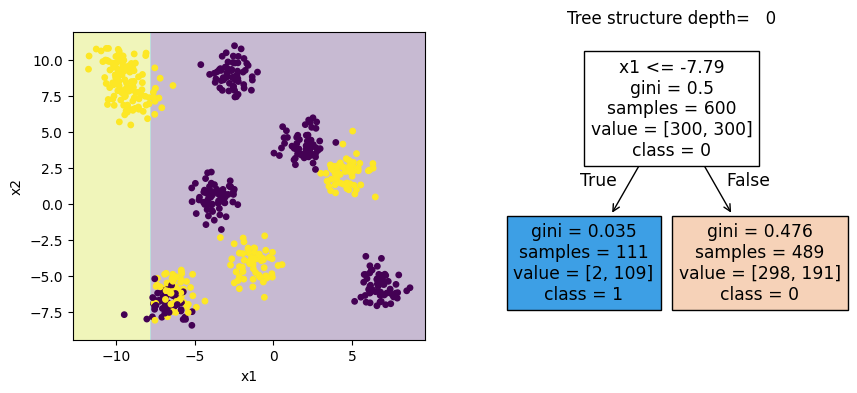

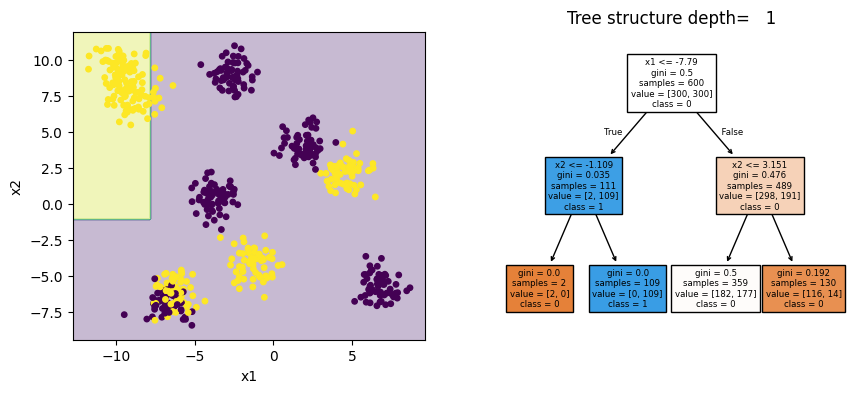

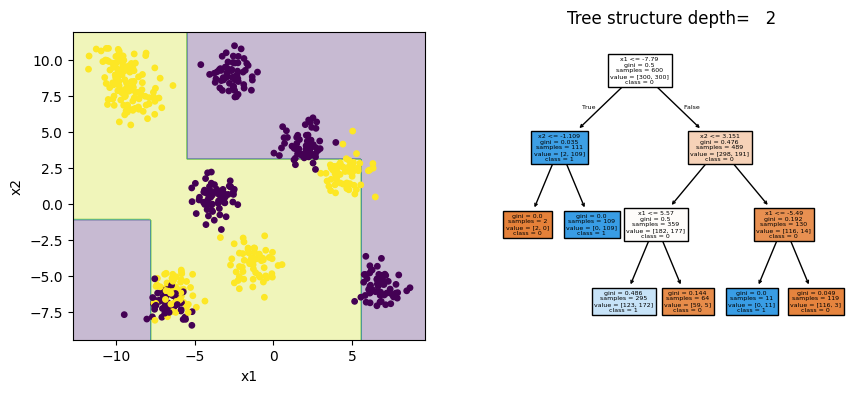

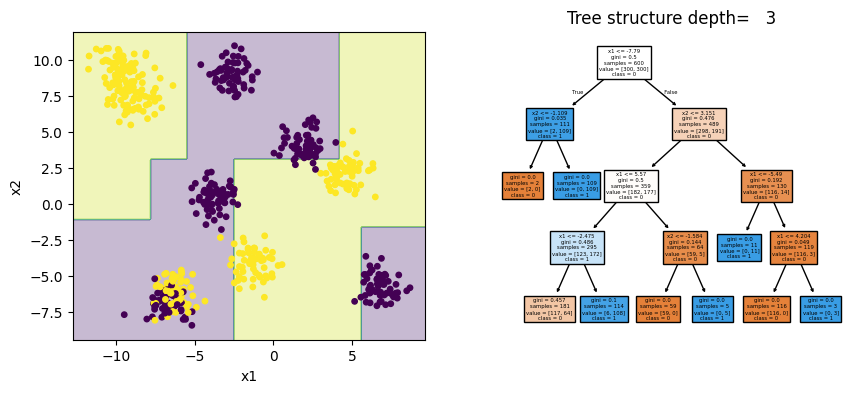

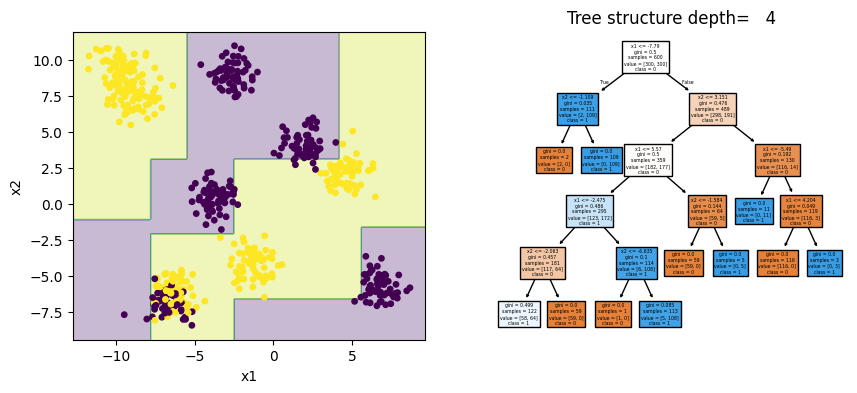

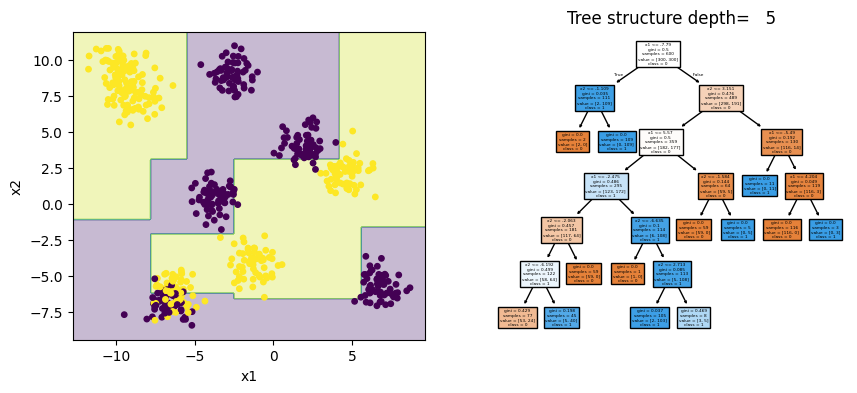

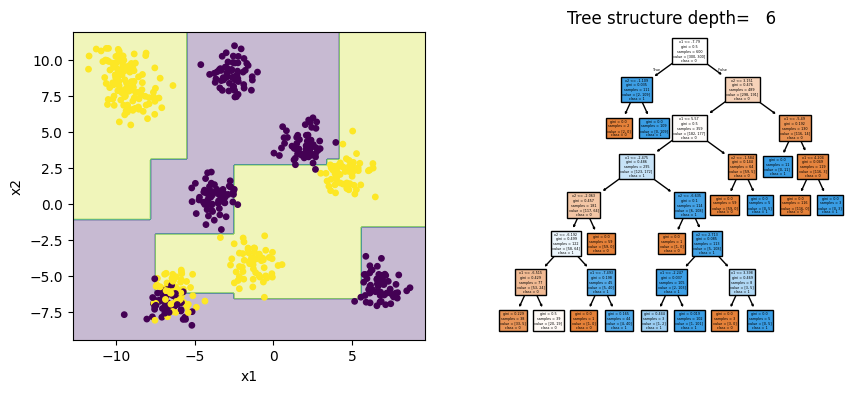

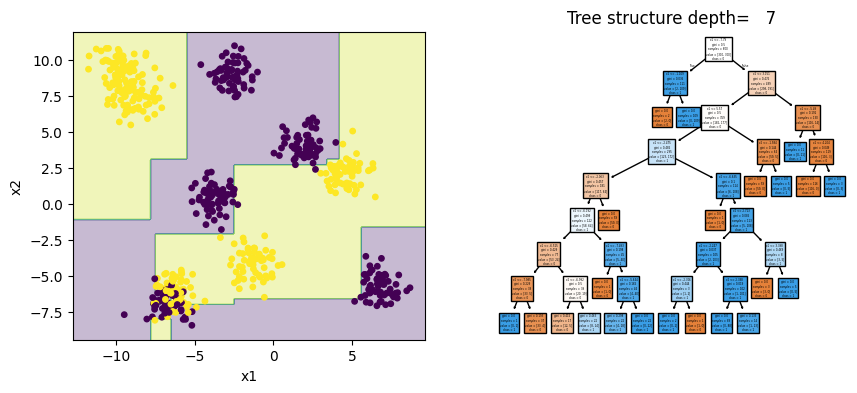

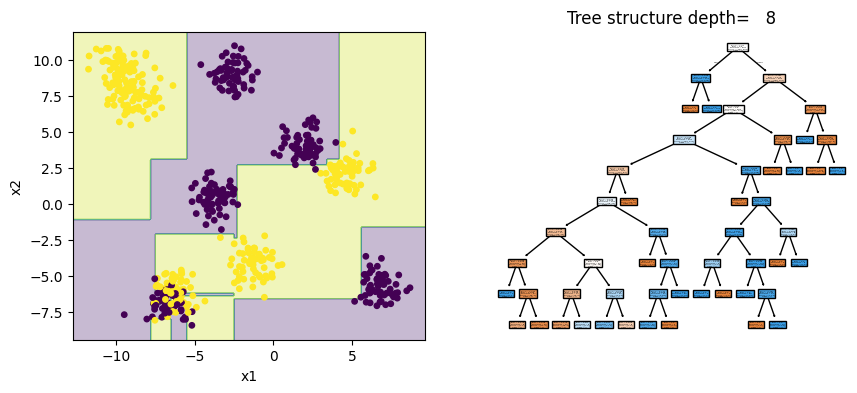

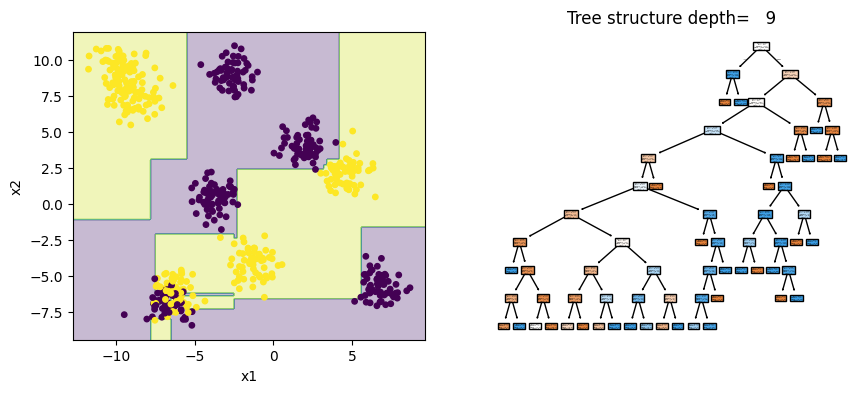

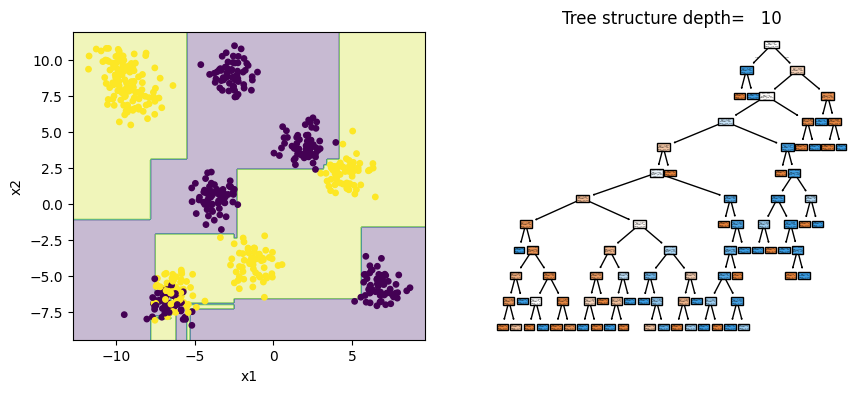

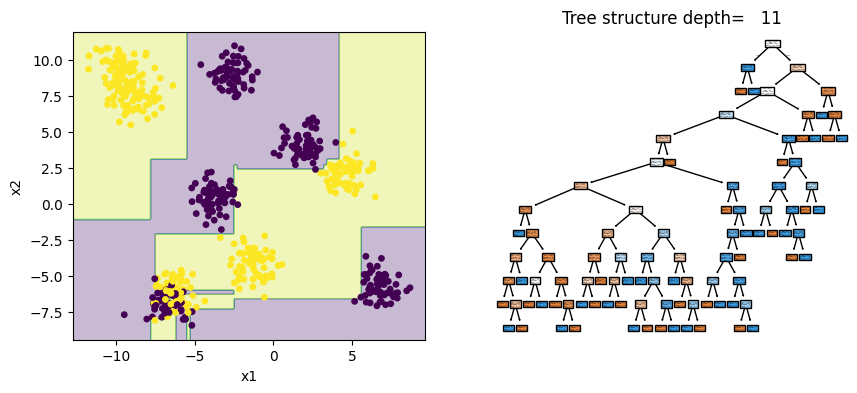

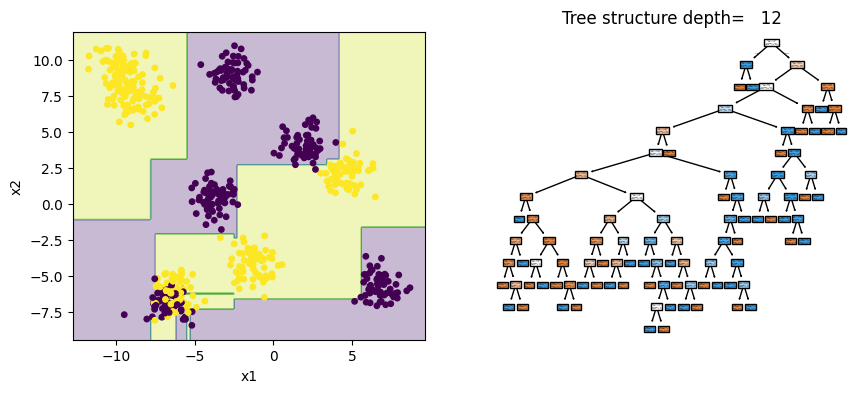

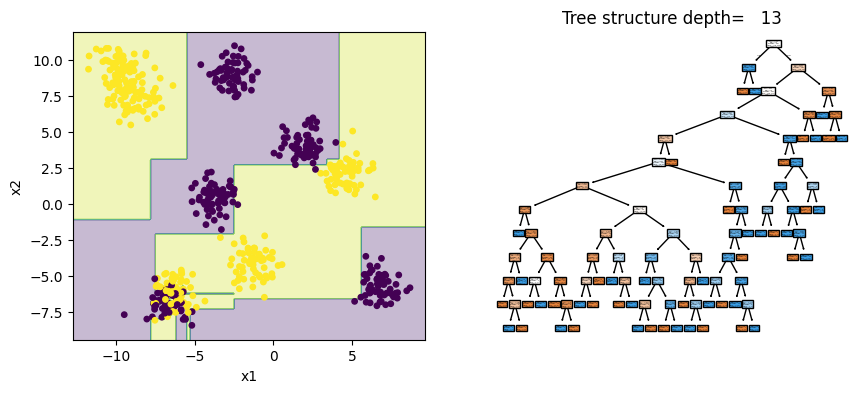

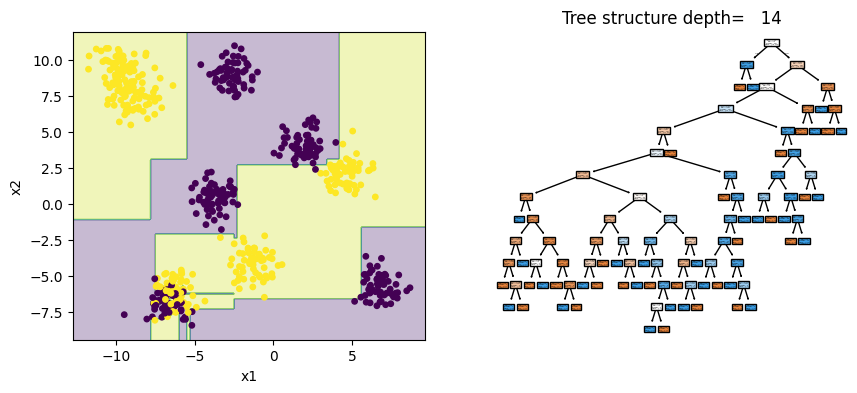

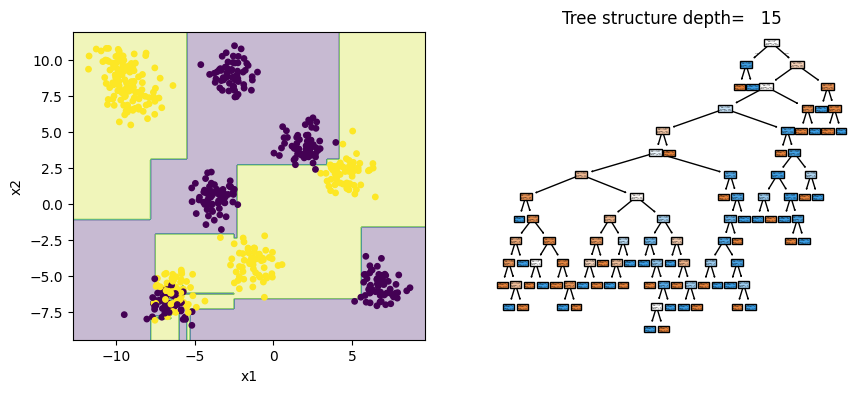

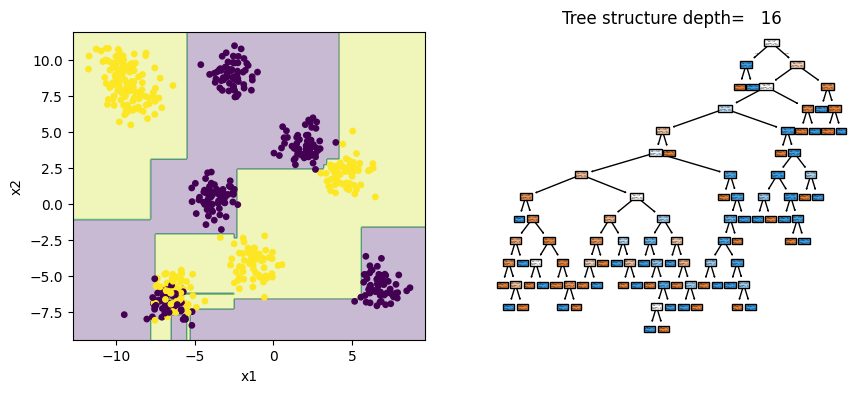

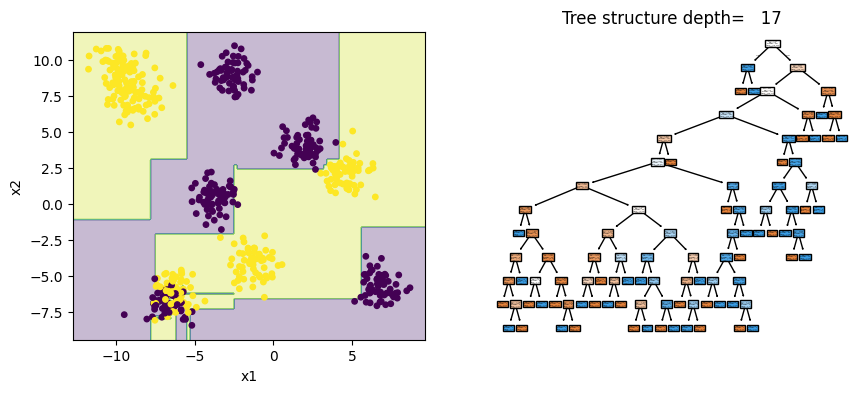

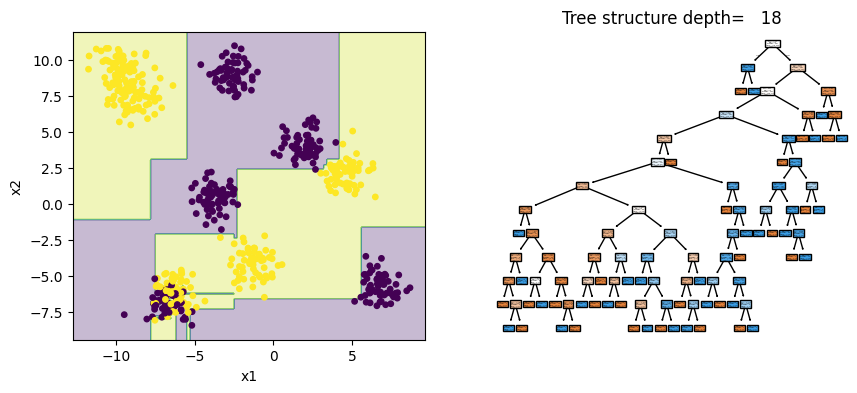

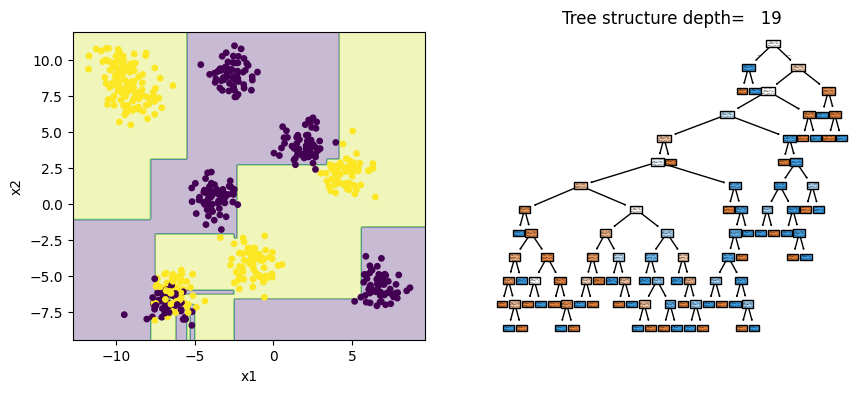

In [35]:

for d in range(max_depth):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.clear()
    # Grid for decision regions
    h = 0.1
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )


    ax1.clear()
    Z = models[d].predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax1.contourf(xx, yy, Z, alpha=0.3)
    ax1.scatter(X[:, 0], X[:, 1], c=y, s=15)

    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")

    # RIGHT: tree
    ax2.clear()
    plot_tree(
        models[d],
        filled=True,
        feature_names=["x1", "x2"],
        class_names=["0", "1"]
    )
    ax2.set_title(f"Tree structure depth=   {d}")



    plt.show()

